## Download Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Path to dataset files: /kaggle/input/default-of-credit-card-clients-dataset


## Install Required Libraries

In [ ]:
!pip install xlrd
!pip install imbalanced-learn

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

## Load Dataset

In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1"

print(os.listdir(dataset_path))

['UCI_Credit_Card.csv']


In [ ]:
file_path = "/root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1/UCI_Credit_Card.csv"

df = pd.read_csv(file_path)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Basic Dataset Info

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (30000, 25)

Columns:

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

Missing Values:

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1          

## Clean Dataset

In [ ]:
df.rename(
    columns={"default payment next month": "default"},
    inplace=True
)

df.drop(columns=["ID"], inplace=True)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Risk Analysis

In [ ]:
print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')


In [ ]:
default_counts = df['default.payment.next.month'].value_counts()

print(default_counts)

default_rate = df['default.payment.next.month'].mean() * 100

print(f"\nDefault Rate: {default_rate:.2f}%")

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Default Rate: 22.12%


## Default Distribution Visualization

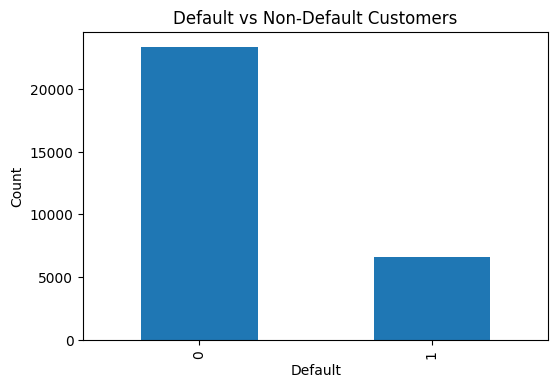

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df['default.payment.next.month'].value_counts().plot(kind='bar')

plt.title("Default vs Non-Default Customers")
plt.xlabel("Default")
plt.ylabel("Count")

plt.show()

## Correlation Heatmap

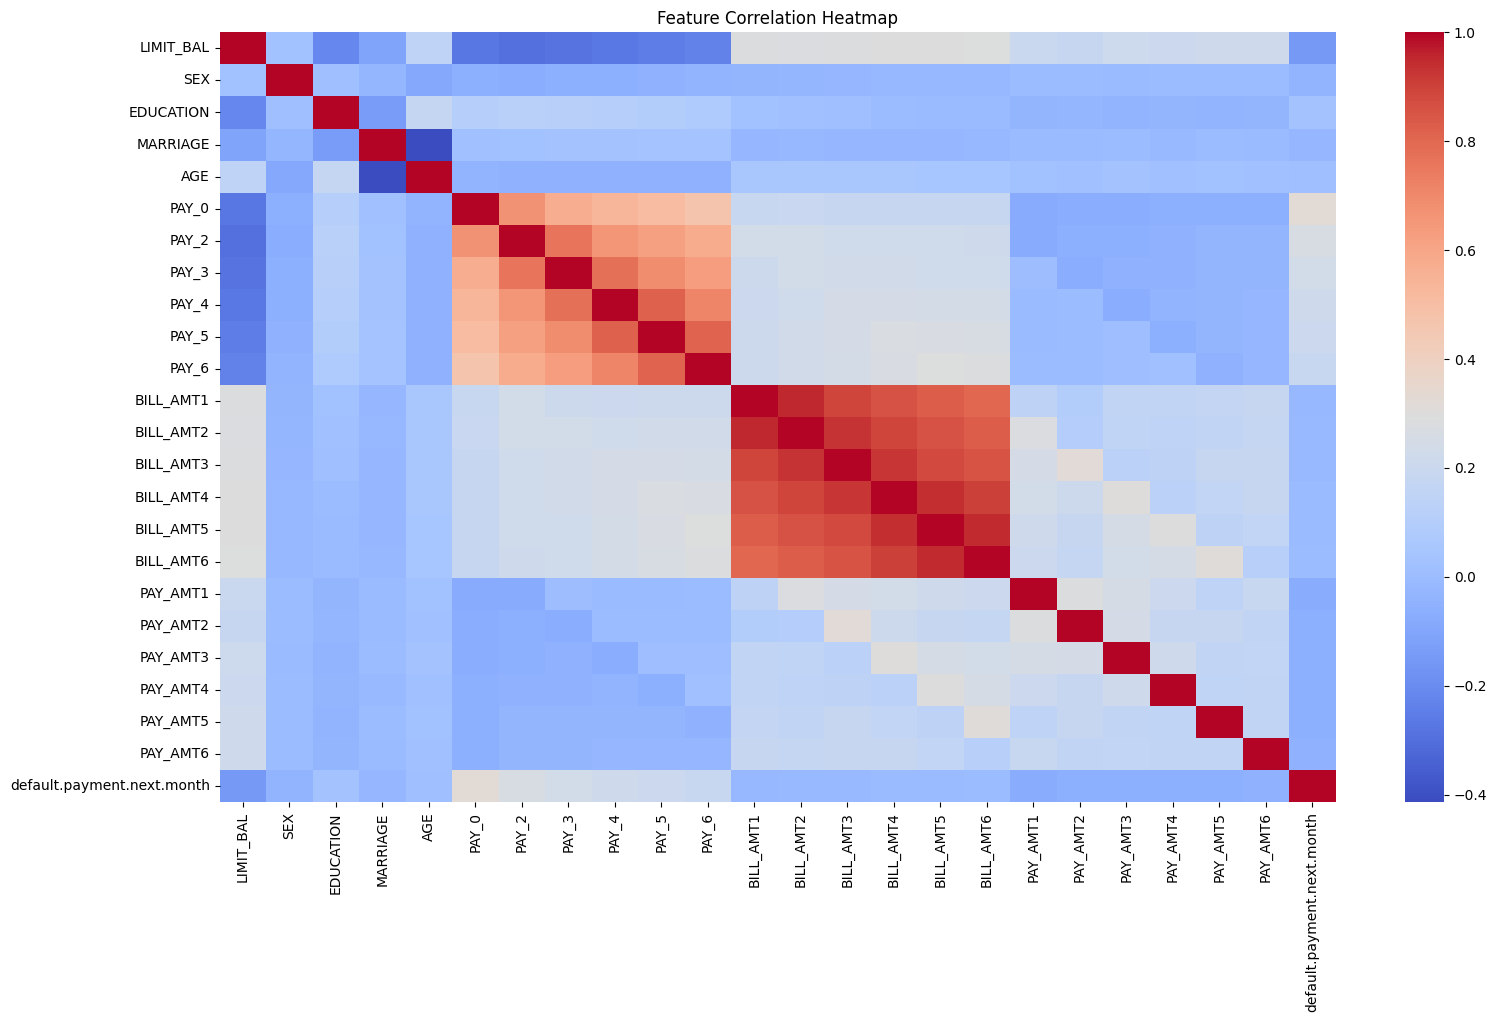

In [ ]:
import seaborn as sns

plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Feature & Target Split

In [ ]:
X = df.drop(
    'default.payment.next.month',
    axis=1
)

y = df['default.payment.next.month']

### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Apply SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
default.payment.next.month
0    18677
1     5323
Name: count, dtype: int64

After SMOTE:
default.payment.next.month
0    18677
1    18677
Name: count, dtype: int64


## Train Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_resampled,
    y_resampled
)

RandomForestClassifier(random_state=42)

## Make Predictions

In [ ]:
y_pred = model.predict(X_test)

## Evaluate Model

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

print(classification_report(
    y_test,
    y_pred
))

roc = roc_auc_score(
    y_test,
    y_pred
)

print("\nROC-AUC Score:", roc)

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4687
           1       0.51      0.49      0.50      1313

    accuracy                           0.79      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.79      0.78      6000


ROC-AUC Score: 0.6787646178577911


## Feature Importance Table

In [ ]:
importance = model.feature_importances_

features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

features = features.sort_values(
    by='Importance',
    ascending=False
)

features.head(10)

,Feature,Importance
5,PAY_0,0.083230
0,LIMIT_BAL,0.059982
11,BILL_AMT1,0.057957
17,PAY_AMT1,0.053594
4,AGE,0.053036
6,PAY_2,0.052741
18,PAY_AMT2,0.048564
12,BILL_AMT2,0.048484
19,PAY_AMT3,0.047640
22,PAY_AMT6,0.046200


## Feature Importance Visualization

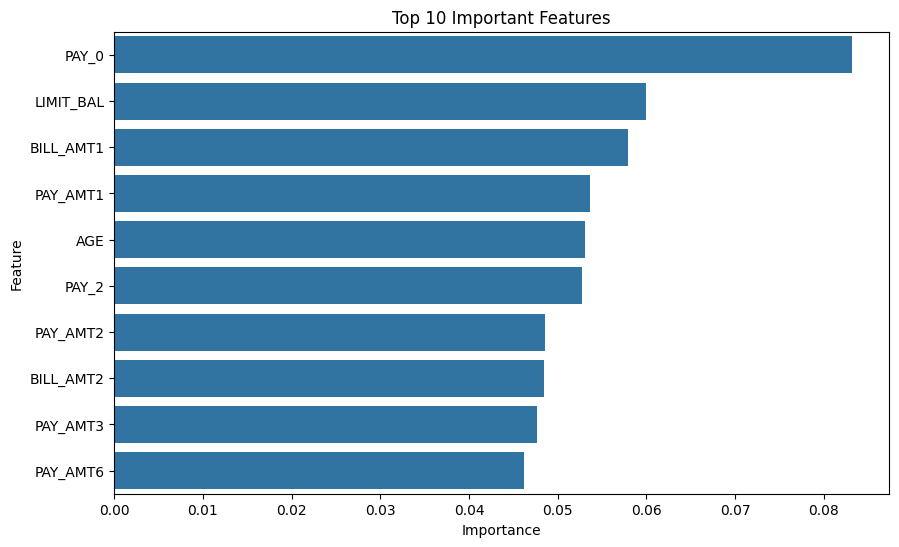

In [ ]:
top_features = features.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

## Export Dataset for Power BI

In [ ]:
df.to_csv(
    "credit_risk_cleaned.csv",
    index=False
)

## Install XGBoost

In [ ]:
!pip install xgboost

## Train XGBoost Model

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_resampled,
    y_resampled
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## Predictions

In [ ]:
xgb_pred = xgb_model.predict(X_test)

## Evaluation

In [ ]:
print(classification_report(
    y_test,
    xgb_pred
))

xgb_roc = roc_auc_score(
    y_test,
    xgb_pred
)

print("\nXGBoost ROC-AUC:", xgb_roc)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4687
           1       0.48      0.51      0.49      1313

    accuracy                           0.77      6000
   macro avg       0.67      0.68      0.67      6000
weighted avg       0.78      0.77      0.77      6000


XGBoost ROC-AUC: 0.6779357302555024


## Feature Importance (Random Forest)

In [ ]:
importance = model.feature_importances_

features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

features = features.sort_values(
    by='Importance',
    ascending=False
)

features.head(10)

,Feature,Importance
5,PAY_0,0.083230
0,LIMIT_BAL,0.059982
11,BILL_AMT1,0.057957
17,PAY_AMT1,0.053594
4,AGE,0.053036
6,PAY_2,0.052741
18,PAY_AMT2,0.048564
12,BILL_AMT2,0.048484
19,PAY_AMT3,0.047640
22,PAY_AMT6,0.046200


## Feature Importance Graph

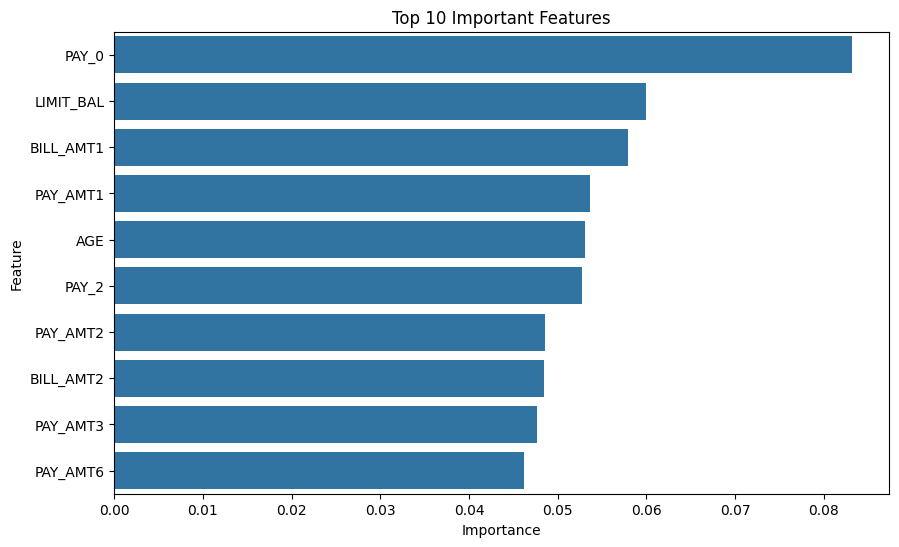

In [ ]:
top_features = features.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

# Business Insights

Business Insights:
- Payment delay history variables (PAY_0 to PAY_6) were among the strongest predictors of customer default risk.
- Customers with prolonged delayed payments exhibited significantly higher probability of default.
- Random Forest outperformed XGBoost slightly on the SMOTE-balanced dataset.
- Class imbalance handling using SMOTE improved minority-risk detection capability.
- Financial repayment behavior plays a major role in credit risk assessment.

In [ ]:
df.to_csv(
    "credit_risk_cleaned.csv",
    index=False
)